## Linear Regression Practical

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [2]:
df=pd.read_csv(r"E:\AI-ML-DS\Data\height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


In [5]:
df.isna().sum()

Weight    0
Height    0
dtype: int64

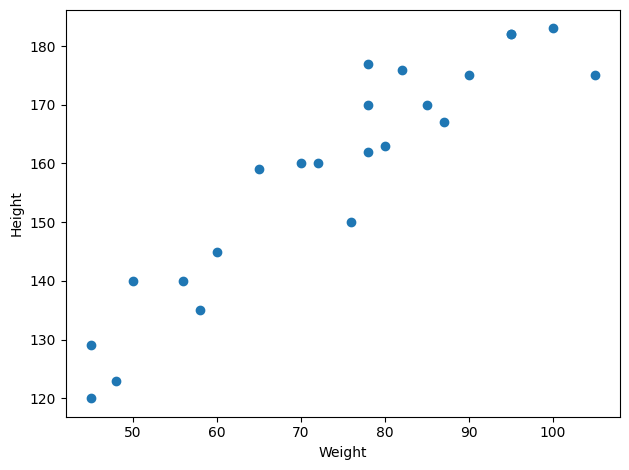

In [18]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')    
plt.tight_layout()

plt.show()



In [ ]:
X=df[['Weight']] # Independent variable
y=df['Height'] # Dependent variable


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

In [22]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [ ]:
 #Standardization and Normalization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [47]:
lr=LinearRegression()
lr.fit(X_train_scaled,y_train)
y_pred=lr.predict(X_test_scaled)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print("Mean Squared Error:",mse)
print("R-squared:(%)",r2*100)

Mean Squared Error: 114.84069295228699
R-squared:(%) 73.60826717981276


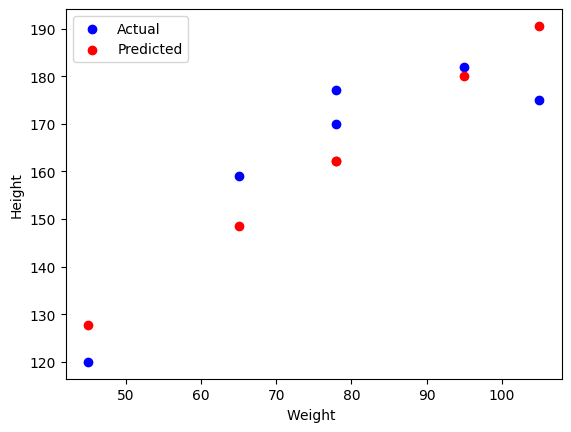

In [46]:
plt.scatter(X_test,y_test,color='blue',label='Actual')
plt.scatter(X_test,y_pred,color='red',label='Predicted')
plt.xlabel('Weight ')
plt.ylabel('Height')
plt.legend()

In [ ]:
lr.coef_,lr.intercept_ # Coefficient represent the slope of regression line and intercept is the best fit line intercept when x=0

(array([17.2982057]), np.float64(156.47058823529412))

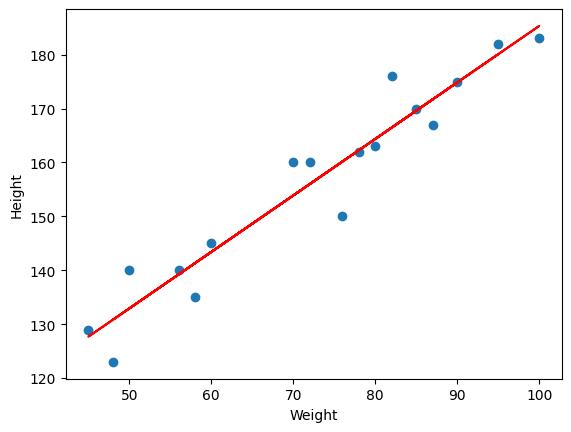

In [42]:
plt.scatter(X_train,y_train)
plt.plot(X_train,lr.predict(X_train_scaled),color='red')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [ ]:
# Predicting for new data point
scaled_weight=scaler.transform([[110]])
lr.predict(scaled_weight)

C:\Users\Devendra\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([195.79859806])

Text(0, 0.5, 'Predicted Height')

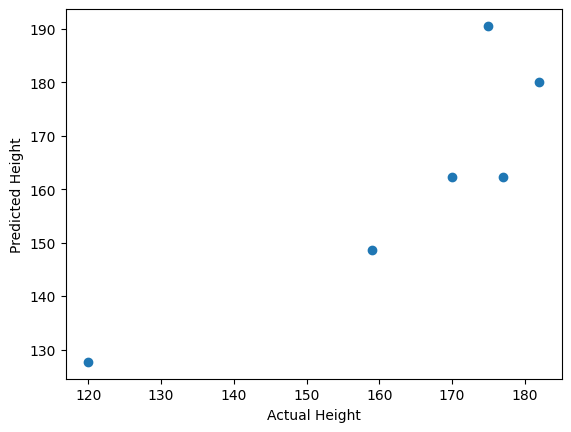

In [53]:
plt.scatter(y_test,y_pred) # Linear Relationship shows that the model is performing well
plt.xlabel('Actual Height')
plt.ylabel('Predicted Height')

C:\Users\Devendra\AppData\Local\Temp\ipykernel_10000\3940983408.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: xlabel='Height', ylabel='Density'>

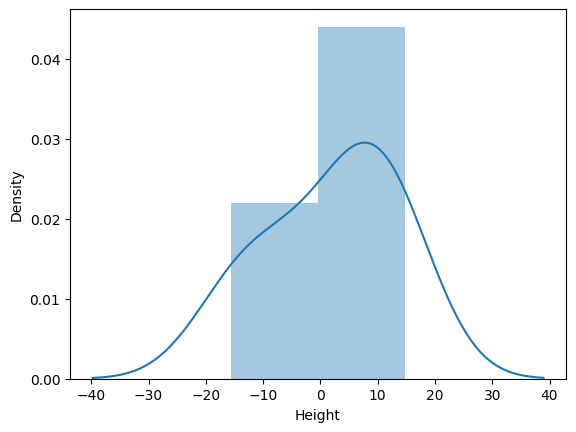

In [ ]:
# Plotting residuals
residuals=y_test-y_pred
sns.distplot(residuals,kde=True) #Uniform Distribution of residuals shows that the model is performing well

Text(0, 0.5, 'Residuals')

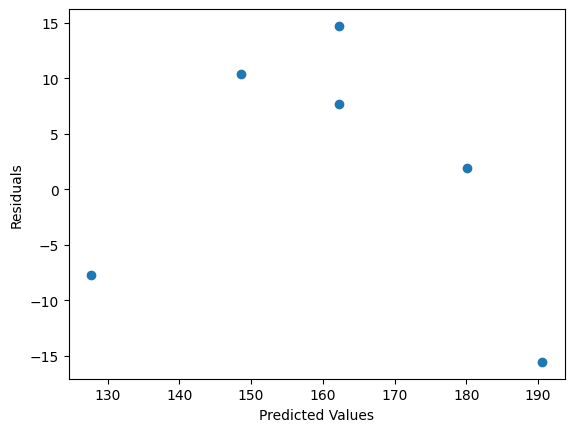

In [ ]:
# Plot between predicted values and residual
plt.scatter(y_pred,residuals) # If there is no pattern/uniform distribution in the plot then the model is performing well
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')